# Stock Return Analysis using CAPM

## Overview

This project analyzes stock returns using real market data and applies the Capital Asset Pricing Model (CAPM) to estimate systematic risk.

The analysis compares Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA) against the S&P500 market index.

## 1. Import Libraries

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## 2. Data Collection

In [19]:
market = yf.download(
    "^GSPC",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

market_return = market["Adj Close"].squeeze().pct_change()

market_return.head()

[*********************100%***********************]  1 of 1 completed


,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007060
2020-01-06,0.003533
2020-01-07,-0.002803
2020-01-08,0.004902


## 3. Exploratory Data Analysis

This section explores the characteristics of stock and market returns using descriptive statistics and visualizations.

In [20]:
# Download Apple data

stock = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

stock_return = stock["Adj Close"].squeeze().pct_change()

aapl_data = pd.DataFrame({
    "AAPL_Return": stock_return,
    "Market_Return": market_return
})

aapl_data = aapl_data.dropna()

aapl_data.head()

[*********************100%***********************]  1 of 1 completed


,AAPL_Return,Market_Return
Date,,
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007969,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016086,0.004902
2020-01-09,0.021241,0.006655


In [21]:
aapl_data.describe()

,AAPL_Return,Market_Return
count,1257.000000,1257.000000
mean,0.001182,0.000561
std,0.019956,0.013443
min,-0.128647,-0.119841
25%,-0.008425,-0.005307
50%,0.001187,0.000888
75%,0.011989,0.007266
max,0.119808,0.093828


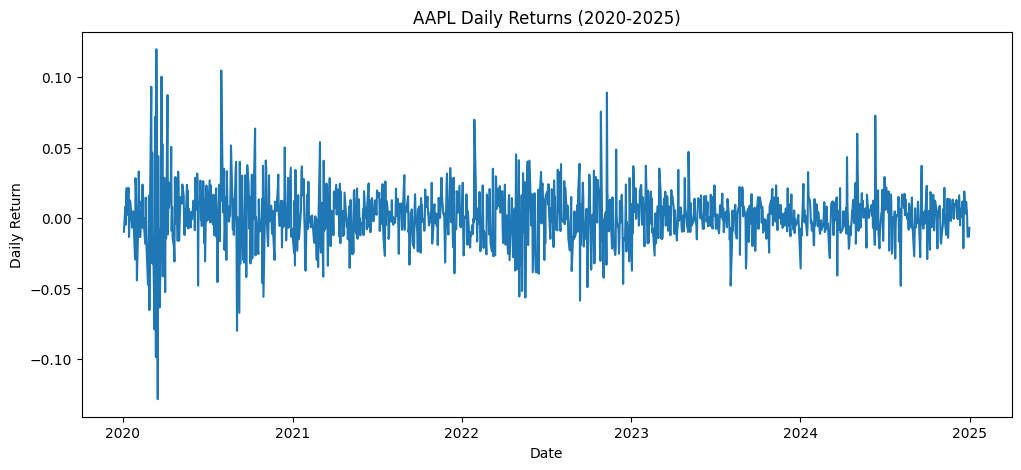

In [22]:
plt.figure(figsize=(12,5))

plt.plot(
    aapl_data.index,
    aapl_data["AAPL_Return"]
)

plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("AAPL Daily Returns (2020-2025)")

plt.show()

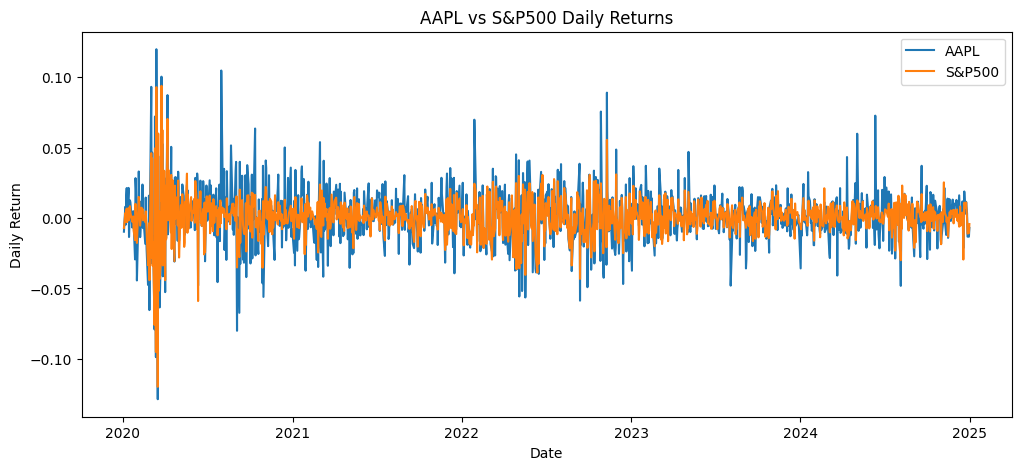

In [23]:
plt.figure(figsize=(12,5))

plt.plot(
    aapl_data.index,
    aapl_data["AAPL_Return"],
    label="AAPL"
)

plt.plot(
    aapl_data.index,
    aapl_data["Market_Return"],
    label="S&P500"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("AAPL vs S&P500 Daily Returns")

plt.legend()
plt.show()

## 4. CAPM Regression Model

The Capital Asset Pricing Model (CAPM) describes the relationship between a stock's return and the overall market return.

The model is defined as:

R_stock = α + β R_market + ε

Where:
- α represents the stock's excess return (Alpha)
- β represents the sensitivity of the stock to market movements (Beta)
- ε represents the unexplained component

In [24]:
X = aapl_data[["Market_Return"]]
y = aapl_data["AAPL_Return"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [25]:
beta = model.coef_[0]
alpha = model.intercept_

prediction = model.predict(X)

r2 = r2_score(y, prediction)

print("Beta:", beta)
print("Alpha:", alpha)
print("R2 Score:", r2)

Beta: 1.1733114135180902
Alpha: 0.0005240353608974521
R2 Score: 0.6247114044277327


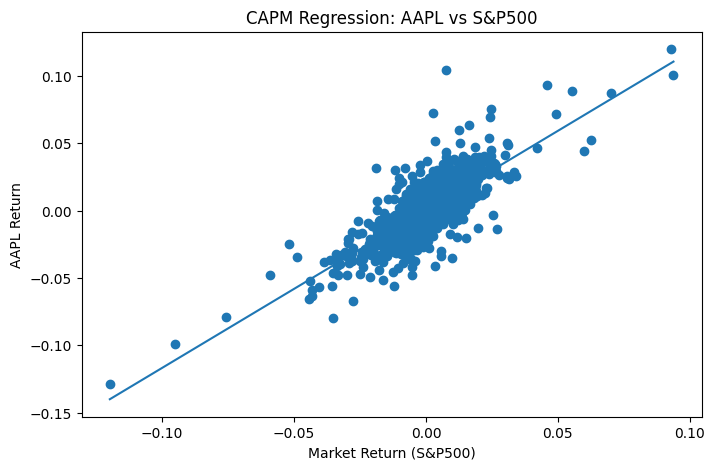

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    aapl_data["Market_Return"],
    aapl_data["AAPL_Return"]
)

x_line = np.linspace(
    aapl_data["Market_Return"].min(),
    aapl_data["Market_Return"].max(),
    100
)

y_line = alpha + beta * x_line

plt.plot(
    x_line,
    y_line
)

plt.xlabel("Market Return (S&P500)")
plt.ylabel("AAPL Return")

plt.title("CAPM Regression: AAPL vs S&P500")

plt.show()

In [27]:
def analyze_stock(stock_symbol):

    stock = yf.download(
        stock_symbol,
        start="2020-01-01",
        end="2025-01-01",
        auto_adjust=False
    )

    stock_return = stock["Adj Close"].squeeze().pct_change()

    data = pd.DataFrame({
        "stock_return": stock_return,
        "market_return": market_return
    })

    data = data.dropna()

    X = data[["market_return"]]
    y = data["stock_return"]

    model = LinearRegression()
    model.fit(X, y)

    prediction = model.predict(X)

    return {
        "Stock": stock_symbol,
        "Beta": model.coef_[0],
        "Alpha": model.intercept_,
        "R2": r2_score(y, prediction),
        "Volatility": data["stock_return"].std()
    }

## 5. Multi-Stock CAPM Comparison

This section compares the systematic risk and performance characteristics of multiple stocks using the CAPM model.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


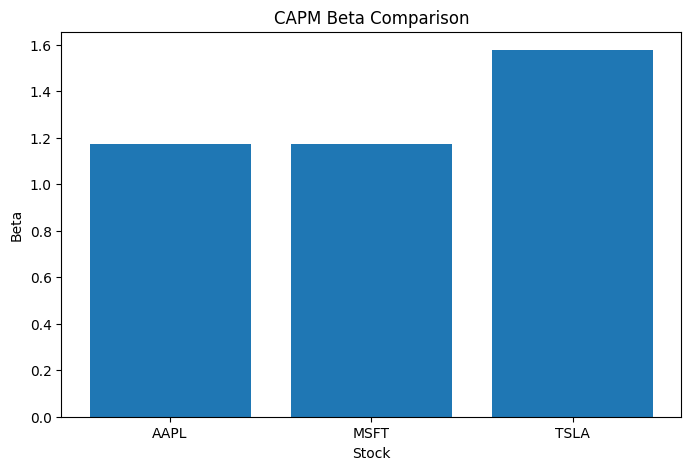

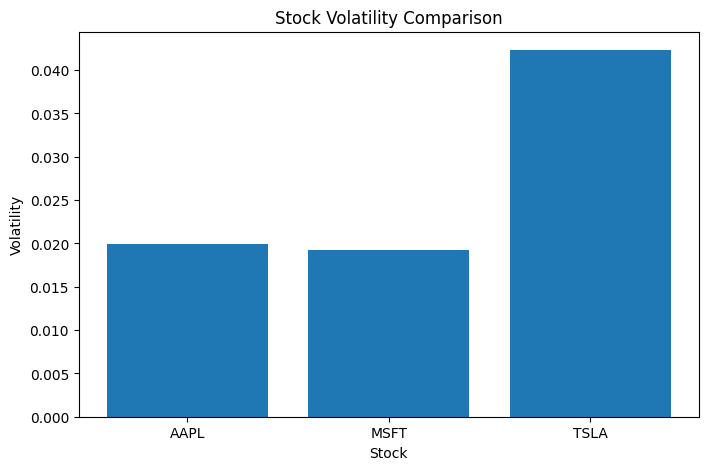

In [28]:
stocks = ["AAPL", "MSFT", "TSLA"]

results = []

for stock in stocks:
    results.append(analyze_stock(stock))

results_df = pd.DataFrame(results)

results_df

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Stock"],
    results_df["Beta"]
)

plt.xlabel("Stock")
plt.ylabel("Beta")
plt.title("CAPM Beta Comparison")

plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Stock"],
    results_df["Volatility"]
)

plt.xlabel("Stock")
plt.ylabel("Volatility")
plt.title("Stock Volatility Comparison")

plt.show()